# Solar PV Production Forecasting — Combined Final Submission

**Shawn Cunningham — Layer 3 Development Inc.**
UC Berkeley AI/ML Professional Certificate · Capstone

This single notebook contains the **complete analysis** — Phase 1 (data
understanding, cleaning, EDA, feature engineering) and Phase 2 (model
comparison, tuning, interpretation, generalization, forecasting) — as one
self-contained, top-to-bottom walkthrough. All code is inlined; it depends only
on the cached data files in `data/`.

**Goal.** Predict a solar array's AC power output from weather and time-of-day
information, identify which inputs matter most, and test whether the model
generalizes to new sites and forecast horizons.

**Non-technical summary:** see [`README.md`](README.md).
**Plain-English definitions:** see [`GLOSSARY.md`](GLOSSARY.md).

## Contents

0. [Setup](#setup)
1. [Data Loading](#s1)
2. [Exploratory Data Analysis](#s2)
3. [Train/Test Split](#s3)
4. [Feature Engineering](#s4)
5. [Regression Modeling](#s5)
6. [Hyperparameter Tuning](#s6)
7. [Selecting the Best Model](#s7)
8. [Model Interpretation](#s8)
9. [Results](#s9)
10. [Save Model](#s10)
11. [Cross-Site Generalization](#s11)
12. [H-Step Forecasting](#s12)
13. [Vision-Based Irradiance Proxy](#s13)
14. [Conclusions](#s14)
15. [References](#s15)

<a id="setup"></a>
## 0. Setup

We import the full stack and fix random seeds for reproducibility. **TensorFlow
is imported first** (before pandas/pvlib/xgboost): on macOS, multiple OpenMP
runtimes otherwise deadlock TensorFlow's thread pool. Single-thread ops +
op-determinism make the LSTM reproducible run-to-run.

In [1]:
# TensorFlow FIRST (macOS OpenMP-deadlock workaround), then the rest.
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import tensorflow as tf
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.experimental.enable_op_determinism()

import warnings, pickle, joblib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pvlib
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

# System 4902 (NIST Ground-1, Gaithersburg MD) configuration.
CONFIG = dict(capacity_kw=270.7, lat=39.1319, lon=-77.2141, elev_m=138,
              tz_offset_hours=-5, tilt_deg=20.0, azimuth_deg=180.0, test_size=0.2)
CAP = CONFIG['capacity_kw']
DATA = Path('data')

def rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))

import sys, contextlib
@contextlib.contextmanager
def suppress_cpp_stderr():
    """Silence TensorFlow's harmless C++/absl stderr notices (tf.data NodeDef
    messages) emitted during LSTM fit/predict, so the notebook output stays
    clean. Redirects the OS-level stderr file descriptor — Python's warnings
    filter cannot intercept C++ writes. Python stdout (epoch logs) is unaffected."""
    sys.stderr.flush()
    saved_fd = os.dup(2)
    devnull_fd = os.open(os.devnull, os.O_WRONLY)
    os.dup2(devnull_fd, 2)
    os.close(devnull_fd)
    try:
        yield
    finally:
        sys.stderr.flush()
        os.dup2(saved_fd, 2)
        os.close(saved_fd)

print('Setup complete.  tensorflow', tf.__version__, '| xgboost', xgb.__version__,
      '| pandas', pd.__version__)

Setup complete.  tensorflow 2.21.0 | xgboost 3.2.0 | pandas 3.0.2


<a id="s1"></a>
## 1. Data Loading

Two real, public datasets:

- **Primary — NREL PVDAQ System 4902** (NIST Ground-1, Gaithersburg MD): a
  270.7 kW ground-mount array, ~112,000 readings at 15-minute cadence,
  July 2014 – March 2018. Channels: AC/DC power, plane-of-array (POA) irradiance
  (the sunlight actually hitting the panels), ambient & module temperature, wind.
- **Secondary — Open-Meteo / ERA5** reanalysis weather (free, CC BY 4.0): cloud
  cover, modeled irradiance, temperature, wind, humidity, pressure — the inputs
  a weather forecast would provide when on-site sensors are unavailable.

Because PVDAQ is *measured* data, it contains real-world artifacts (sensor
gaps/glitches), so we clean it before analysis.

In [2]:
# 1.1 Load primary PVDAQ data (15-minute).
df = pd.read_parquet(DATA / 'nist_ground_4902_15min.parquet').sort_index()
df.index.name = 'timestamp'
print(f'PVDAQ: {df.shape[0]:,} rows x {df.shape[1]} cols  '
      f'({df.index.min()} -> {df.index.max()})')
df.head(3)

PVDAQ: 112,153 rows x 9 cols  (2014-07-29 07:30:00 -> 2018-03-14 23:45:00)


,ac_power_kw,dc_power_kw,poa_irradiance2_wm2,poa_irradiance_wm2,temp_ambient2_c,temp_ambient_c,temp_module_c,wind_speed2_ms,wind_speed_ms
timestamp,,,,,,,,,
2014-07-29 07:30:00,79.781429,85.942857,319.842857,305.085714,17.021429,17.168571,21.298571,4.128571,2.482857
2014-07-29 07:45:00,88.493333,95.080000,354.846667,340.126667,17.113333,17.292667,22.324667,3.266667,2.031667
2014-07-29 08:00:00,102.693333,109.640000,410.593333,396.073333,17.414000,17.589333,23.851333,3.773333,2.304200


In [3]:
# 1.2 Load secondary Open-Meteo / ERA5 weather and standardize names.
om_raw = pd.read_parquet(DATA / 'openmeteo_nist_4902_hourly.parquet').rename(columns={
    'shortwave_radiation':      'om_ghi',   # global horizontal irradiance
    'direct_normal_irradiance': 'om_dni',
    'diffuse_radiation':        'om_dhi',
    'temperature_2m':           'om_temp_2m',
    'windspeed_10m':            'om_wind_10m',
})
OM_FEATURES = ['cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
               'om_ghi', 'om_dni', 'om_dhi', 'om_temp_2m', 'om_wind_10m',
               'relative_humidity_2m', 'surface_pressure']
om = om_raw[OM_FEATURES].copy()
print(f'Open-Meteo: {len(om):,} hourly rows, {len(OM_FEATURES)} weather fields')
om.head(3)

Open-Meteo: 31,824 hourly rows, 11 weather fields


,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,om_ghi,om_dni,om_dhi,om_temp_2m,om_wind_10m,relative_humidity_2m,surface_pressure
measured_on,,,,,,,,,,,
2014-07-28 19:00:00,86,40,83,0,67.0,190.7,37.0,22.9,17.4,57,992.2
2014-07-28 20:00:00,54,0,52,14,4.0,20.2,3.0,21.8,14.8,62,993.1
2014-07-28 21:00:00,32,1,32,0,0.0,0.0,0.0,20.9,13.7,65,994.2


In [4]:
# 1.3 Clean.  Missing data is imputed train/test-aware (no future leakage):
#     the boundary is fixed NOW and reused for the formal split in section 3.
SPLIT_TS = df.index[int(len(df) * (1 - CONFIG['test_size']))]
print(f'Missing cells before: {df.isna().sum().sum()} ({df.isna().sum().sum()/df.size*100:.3f}%)')

train_raw, test_raw = df.loc[df.index < SPLIT_TS], df.loc[df.index >= SPLIT_TS]
train_clean = train_raw.interpolate(method='time', limit=4).ffill().bfill()
test_clean = test_raw.ffill().fillna(train_clean.median(numeric_only=True))
df = pd.concat([train_clean, test_clean])

df = df[~df.index.duplicated(keep='first')]                       # de-duplicate timestamps

# Average the dual-redundant sensor pairs, then drop the spares.
df['poa_irradiance_wm2'] = df[['poa_irradiance_wm2', 'poa_irradiance2_wm2']].mean(axis=1)
df['temp_ambient_c']     = df[['temp_ambient_c', 'temp_ambient2_c']].mean(axis=1)
df['wind_speed_ms']      = df[['wind_speed_ms', 'wind_speed2_ms']].mean(axis=1)
df = df.drop(columns=['poa_irradiance2_wm2', 'temp_ambient2_c', 'wind_speed2_ms'])

# Merge hourly weather onto the 15-min index by forward-fill.
df = df.join(om.reindex(df.index, method='ffill'), how='left')

# Physics-based caps for the few residual anomalies.
df['ac_power_kw']        = df['ac_power_kw'].clip(0, CAP)
df['dc_power_kw']        = df['dc_power_kw'].clip(lower=0)
df['poa_irradiance_wm2'] = df['poa_irradiance_wm2'].clip(0, 1500)
df['wind_speed_ms']      = df['wind_speed_ms'].clip(0, 40)
df['temp_module_c']      = df['temp_module_c'].clip(-25, 85)

print(f'After cleaning: {df.shape[0]:,} rows x {df.shape[1]} cols, '
      f'{df.isna().sum().sum()} missing cells')

Missing cells before: 750 (0.074%)
After cleaning: 112,153 rows x 17 cols, 0 missing cells


<a id="s2"></a>
## 2. Exploratory Data Analysis

We explore the cleaned data to understand its structure before modeling.

### 2.1 Distributions (daytime only)

Roughly half of all 15-minute rows are night-time zeros. We restrict the
power/irradiance distributions to daytime (POA > 50 W/m²) so the shape of the
*productive* hours is visible.

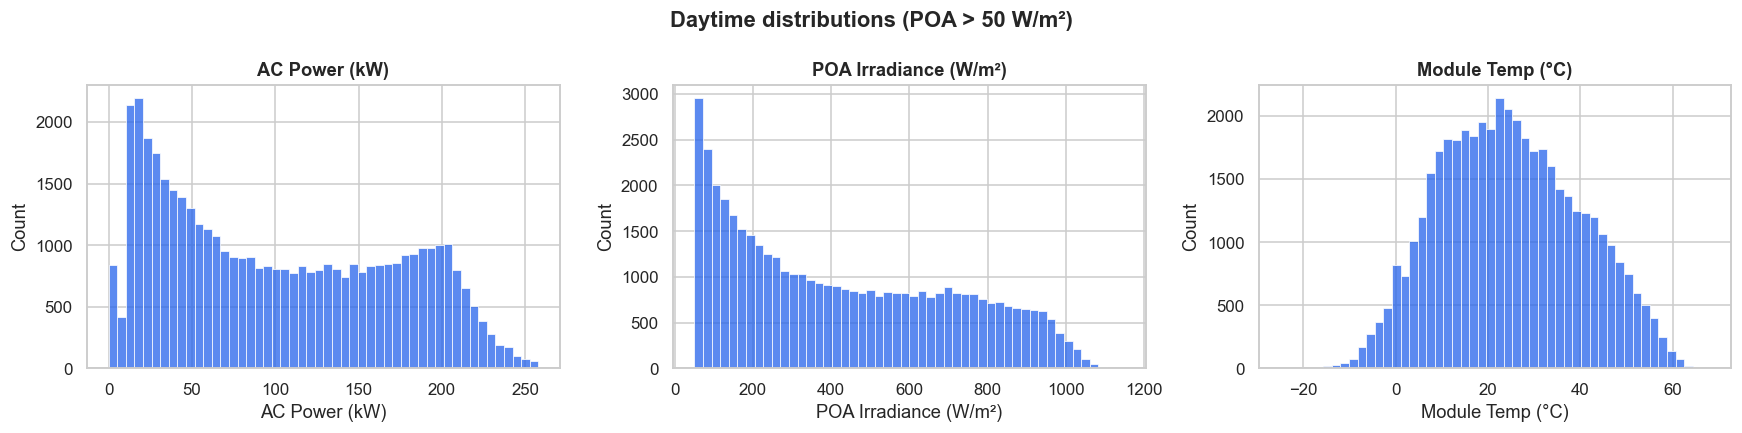

In [5]:
# Restrict to daytime (POA > 50 W/m2) so the productive-hour shape is visible.
daytime = df[df['poa_irradiance_wm2'] > 50]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, title in zip(
        axes,
        ['ac_power_kw', 'poa_irradiance_wm2', 'temp_module_c'],
        ['AC Power (kW)', 'POA Irradiance (W/m²)', 'Module Temp (°C)']):
    sns.histplot(daytime[col], bins=50, ax=ax, color='#2563eb')
    ax.set_title(title, fontweight='bold'); ax.set_xlabel(title)
fig.suptitle('Daytime distributions (POA > 50 W/m²)', fontweight='bold')
plt.tight_layout(); plt.show()

### 2.2 Time-series decomposition

A clean July week, decomposed into trend + a 24-hour (diurnal) seasonal cycle +
residual. The diurnal cycle is the dominant, deterministic component; the
residual is the weather-driven part a model must learn.

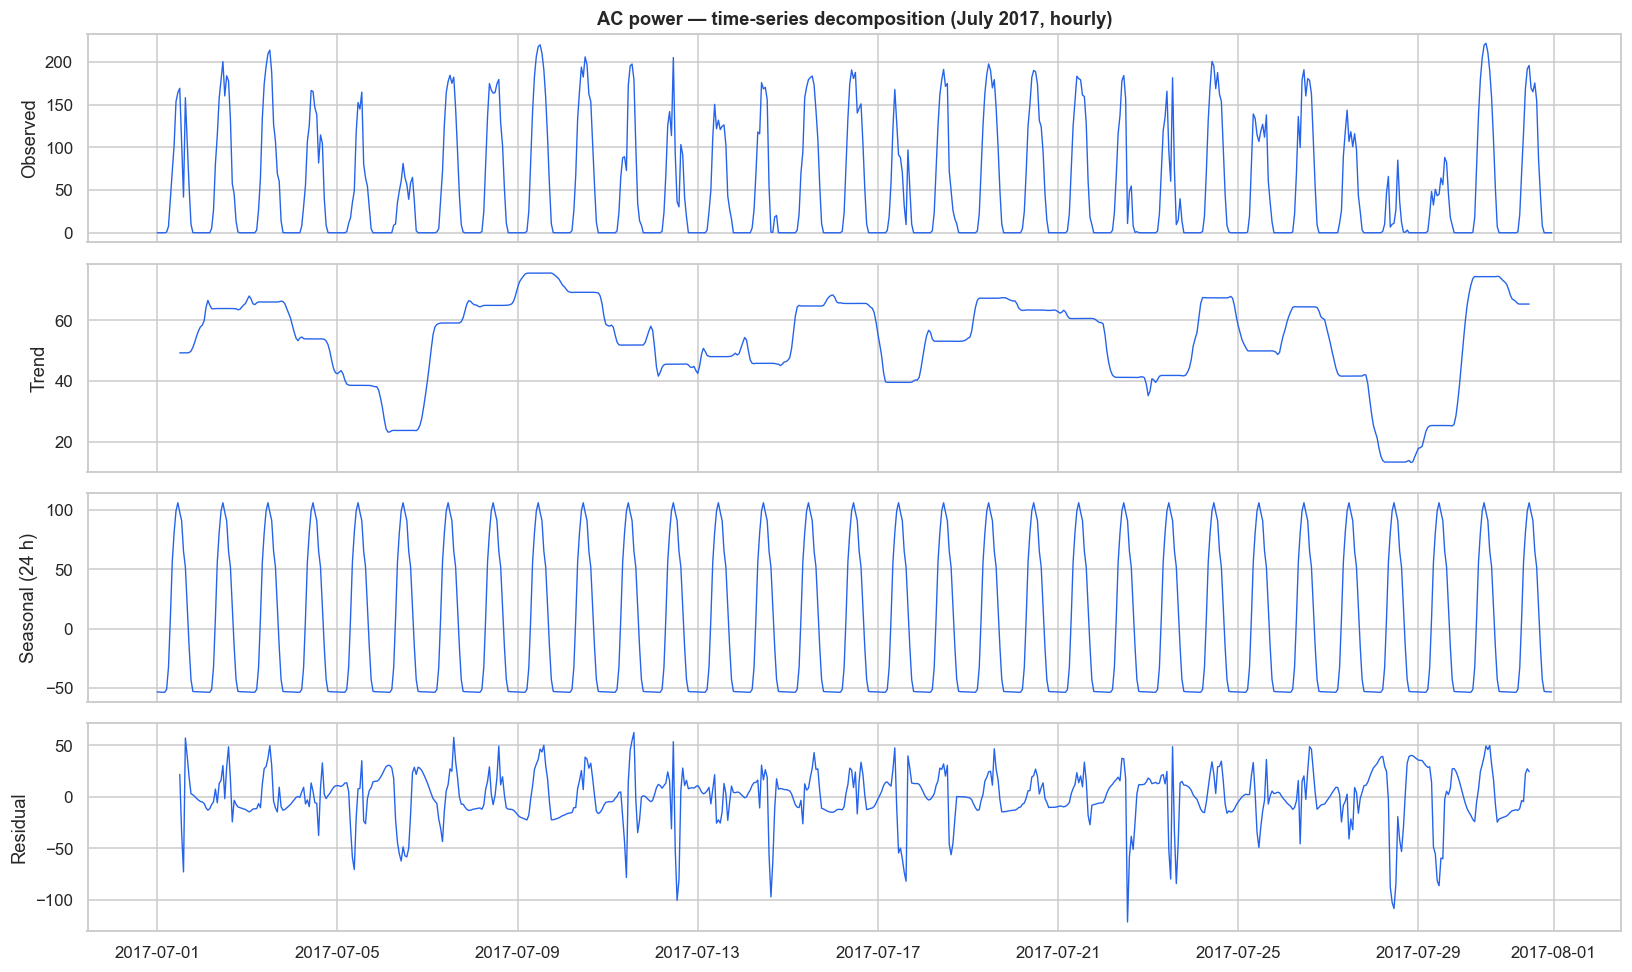

In [6]:
# Decompose a clean July week into trend + 24 h diurnal cycle + residual.
ts = df.loc['2017-07-01':'2017-07-31', 'ac_power_kw'].resample('1h').mean().interpolate()
res = seasonal_decompose(ts, period=24, model='additive')
fig, axes = plt.subplots(4, 1, figsize=(15, 9), sharex=True)
for ax, series, name in zip(axes, [res.observed, res.trend, res.seasonal, res.resid],
                            ['Observed', 'Trend', 'Seasonal (24 h)', 'Residual']):
    ax.plot(series, color='#2563eb', lw=0.9); ax.set_ylabel(name)
axes[0].set_title('AC power — time-series decomposition (July 2017, hourly)', fontweight='bold')
plt.tight_layout(); plt.show()

### 2.3 Diurnal & seasonal patterns

Average output by hour of day (the daily arc) and by month (the seasonal swing).

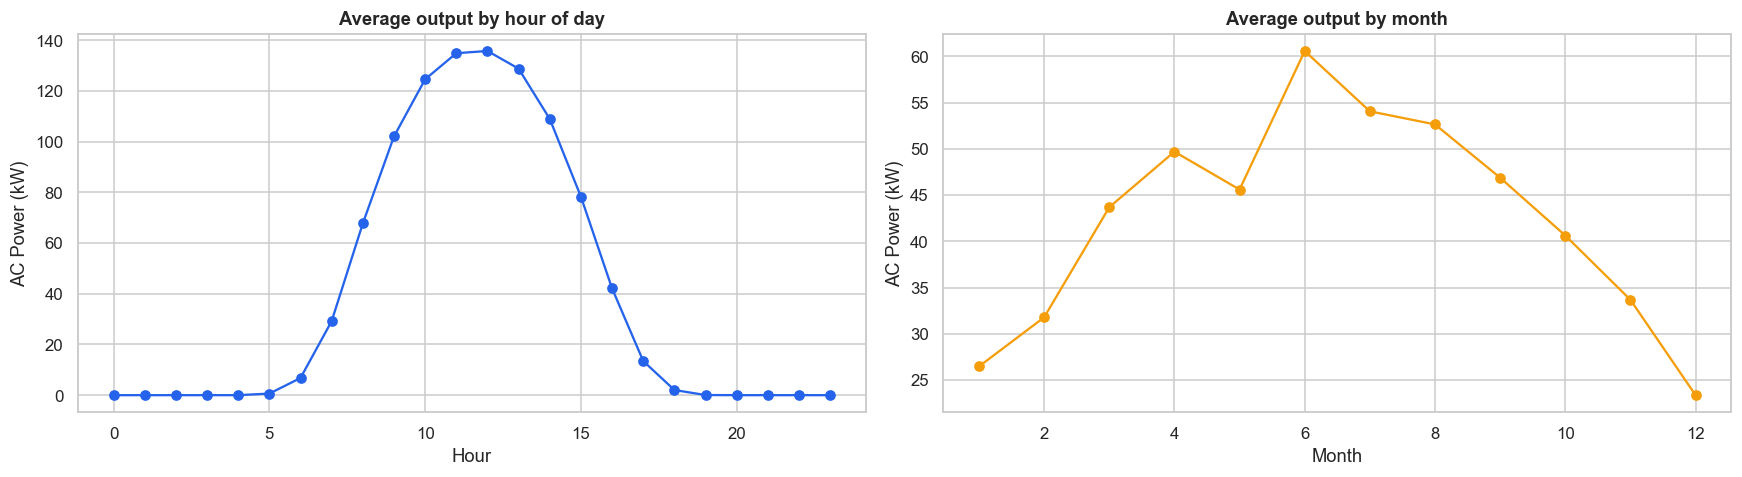

In [7]:
# Average output by hour of day (left) and by month (right).
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
df.groupby(df.index.hour)['ac_power_kw'].mean().plot(
    ax=axes[0], marker='o', color='#2563eb')
axes[0].set_title('Average output by hour of day', fontweight='bold')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('AC Power (kW)')
df.groupby(df.index.month)['ac_power_kw'].mean().plot(
    ax=axes[1], marker='o', color='#f59e0b')
axes[1].set_title('Average output by month', fontweight='bold')
axes[1].set_xlabel('Month'); axes[1].set_ylabel('AC Power (kW)')
plt.tight_layout(); plt.show()

### 2.4 Correlation structure

How the measured channels and weather fields relate to AC power.

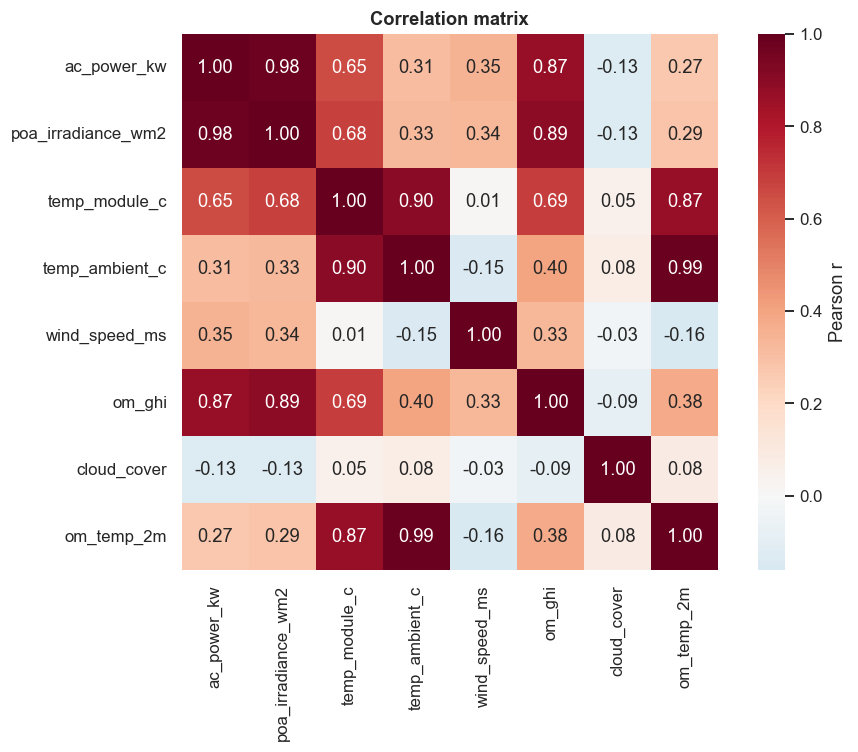

AC power correlates most with measured POA: r = 0.979


In [8]:
# Correlation of measured channels + weather fields against AC power.
corr_cols = ['ac_power_kw', 'poa_irradiance_wm2', 'temp_module_c', 'temp_ambient_c',
             'wind_speed_ms', 'om_ghi', 'cloud_cover', 'om_temp_2m']
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation matrix', fontweight='bold')
plt.tight_layout(); plt.show()
print('AC power correlates most with measured POA: '
      f"r = {df['ac_power_kw'].corr(df['poa_irradiance_wm2']):.3f}")

### 2.5 Driving relationships

POA irradiance is near-linear with AC power; module temperature adds a secondary
thermal-derating effect (hotter panels are slightly less efficient).

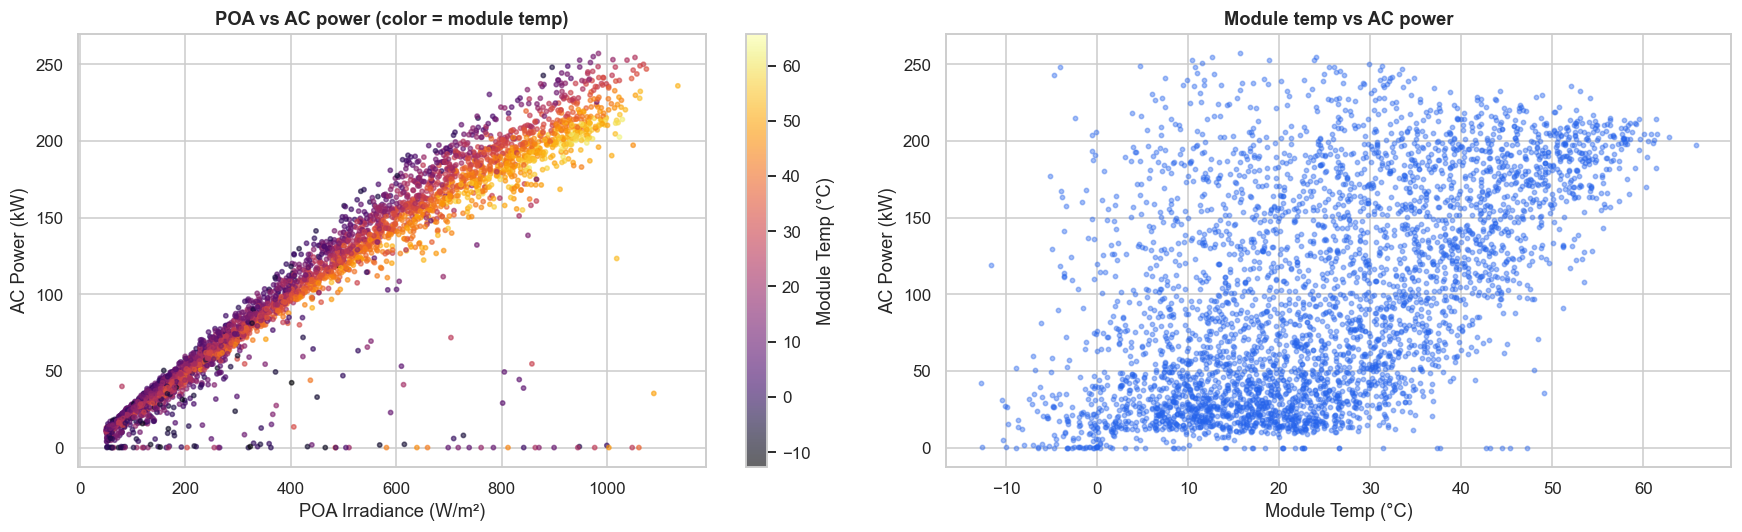

In [9]:
# Sample daytime rows and plot the two main driving relationships.
samp = daytime.sample(min(4000, len(daytime)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sc = axes[0].scatter(samp['poa_irradiance_wm2'], samp['ac_power_kw'],
                     c=samp['temp_module_c'], cmap='inferno', s=8, alpha=0.6)
axes[0].set_xlabel('POA Irradiance (W/m²)'); axes[0].set_ylabel('AC Power (kW)')
axes[0].set_title('POA vs AC power (color = module temp)', fontweight='bold')
fig.colorbar(sc, ax=axes[0], label='Module Temp (°C)')
axes[1].scatter(samp['temp_module_c'], samp['ac_power_kw'], s=8, alpha=0.4, color='#2563eb')
axes[1].set_xlabel('Module Temp (°C)'); axes[1].set_ylabel('AC Power (kW)')
axes[1].set_title('Module temp vs AC power', fontweight='bold')
plt.tight_layout(); plt.show()

### 2.6 Does the weather data align with the on-site sensors?

A sanity check that the merged Open-Meteo fields carry the right signal:
modeled GHI should track measured POA, and modeled temperature/wind should track
the on-site sensors.

In [10]:
# Sanity-check that the merged weather fields track the on-site sensors.
checks = {
    'om_ghi  vs measured POA':      df['om_ghi'].corr(df['poa_irradiance_wm2']),
    'om_temp_2m vs ambient temp':   df['om_temp_2m'].corr(df['temp_ambient_c']),
    'om_wind_10m vs on-site wind':  df['om_wind_10m'].corr(df['wind_speed_ms']),
    'cloud_cover vs AC power':      df['cloud_cover'].corr(df['ac_power_kw']),
}
for k, v in checks.items():
    print(f'  r = {v:+.3f}   {k}')

  r = +0.890   om_ghi  vs measured POA
  r = +0.987   om_temp_2m vs ambient temp
  r = +0.751   om_wind_10m vs on-site wind
  r = -0.130   cloud_cover vs AC power


<a id="s3"></a>
## 3. Train/Test Split

This is time-series data, so we **never** use a random split — that would let the
model peek at the future. We split **chronologically**: the oldest 80% of the
timeline is training, the most recent 20% is the held-out test set. The boundary
timestamp was fixed back in section 1 so cleaning could not leak across it.

In [11]:
# Chronological split: oldest 80% train, most recent 20% test.
train_df = df[df.index < SPLIT_TS].copy()
test_df  = df[df.index >= SPLIT_TS].copy()
print(f'Split boundary : {SPLIT_TS}')
print(f'Train : {len(train_df):>6,} rows  {train_df.index.min().date()} -> {train_df.index.max().date()}')
print(f'Test  : {len(test_df):>6,} rows  {test_df.index.min().date()} -> {test_df.index.max().date()}')

Split boundary : 2017-07-20 04:45:00
Train : 89,722 rows  2014-07-29 -> 2017-07-20
Test  : 22,431 rows  2017-07-20 -> 2018-03-14


<a id="s4"></a>
## 4. Feature Engineering

We add three families of features, applied to the train and test sets
**independently** (each is row-local and deterministic, so nothing leaks):

- **Solar geometry (pvlib):** sun elevation/zenith, angle-of-incidence (AOI) on
  the tilted panel, and clear-sky POA — the *physics* of where the sun is, which
  is free to compute for any future timestamp.
- **Cyclical time:** sine/cosine of hour-of-day and day-of-year (so 23:00 and
  00:00 are adjacent), plus month and a daylight flag.
- **Interactions:** POA × module-temperature (thermal derating) and the
  module−ambient temperature gap.

In [12]:
def add_geometry(d):
    d = d.copy()
    tzs = f"Etc/GMT{-CONFIG['tz_offset_hours']:+d}"          # UTC-5 -> 'Etc/GMT+5'
    times = d.index.tz_localize(tzs)
    site = pvlib.location.Location(CONFIG['lat'], CONFIG['lon'], tzs,
                                   CONFIG['elev_m'], 'NIST Ground-1')
    sp = site.get_solarposition(times)
    d['solar_zenith']    = sp['apparent_zenith'].values
    d['solar_elevation'] = sp['apparent_elevation'].values
    d['aoi'] = pvlib.irradiance.aoi(CONFIG['tilt_deg'], CONFIG['azimuth_deg'],
                                    sp['apparent_zenith'], sp['azimuth']).values
    cs = site.get_clearsky(times, model='ineichen')
    d['clear_sky_poa'] = pvlib.irradiance.get_total_irradiance(
        CONFIG['tilt_deg'], CONFIG['azimuth_deg'], sp['apparent_zenith'], sp['azimuth'],
        dni=cs['dni'], ghi=cs['ghi'], dhi=cs['dhi'])['poa_global'].values
    d['clear_sky_index'] = np.where(d['clear_sky_poa'] > 1.0,
                                    d['poa_irradiance_wm2'] / d['clear_sky_poa'], 0.0).clip(0, 1.5)
    return d

def add_temporal(d):
    d = d.copy()
    hour = d.index.hour + d.index.minute / 60.0
    doy = d.index.dayofyear
    d['hour_sin'] = np.sin(2*np.pi*hour/24); d['hour_cos'] = np.cos(2*np.pi*hour/24)
    d['doy_sin']  = np.sin(2*np.pi*doy/365); d['doy_cos']  = np.cos(2*np.pi*doy/365)
    d['month'] = d.index.month
    d['is_daylight'] = (d['solar_elevation'] > 0).astype(int)
    d['poa_x_module_temp'] = d['poa_irradiance_wm2'] * d['temp_module_c']
    d['temp_delta'] = d['temp_module_c'] - d['temp_ambient_c']
    return d

train_df = add_temporal(add_geometry(train_df)).drop(columns=['dc_power_kw']).dropna()
test_df  = add_temporal(add_geometry(test_df)).drop(columns=['dc_power_kw']).dropna()

# Two feature sets:
#  FULL     — every on-site sensor incl. measured POA (the "nowcast" upper bound).
#  FORECAST — NO on-site sensors: only deterministic geometry/time + weather
#             proxies. This is the realistic deployment scenario.
TARGET = 'ac_power_kw'
FULL_FEATURES = ['poa_irradiance_wm2', 'temp_ambient_c', 'temp_module_c', 'wind_speed_ms',
                 'aoi', 'clear_sky_index', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos',
                 'month', 'is_daylight', 'poa_x_module_temp', 'temp_delta']
FORECAST_FEATURES = ['aoi', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month',
                     'is_daylight'] + OM_FEATURES
print(f'FULL feature set     : {len(FULL_FEATURES)} features (with on-site sensors)')
print(f'FORECAST feature set : {len(FORECAST_FEATURES)} features (no on-site sensors)')

FULL feature set     : 14 features (with on-site sensors)
FORECAST feature set : 18 features (no on-site sensors)


<a id="s5"></a>
## 5. Regression Modeling

This is a **regression** problem (predict a continuous kW value), so we compare
regression models.

**Evaluation metric.** Our primary metric is **RMSE** (root-mean-squared error,
in kW): it punishes big misses hardest, which matters here because a large
forecast error is far more costly than several small ones. We also report **R²**
(fraction of variance explained), **MAE** (average miss), and daytime **MAPE**
(percentage error). We score on the held-out test set.

We model under two feature scenarios, then compare model architectures.

In [13]:
# Scoring helper: RMSE (primary), MAE, R2, and daytime MAPE.
def score(name, y_true, y_pred, thr=10.0, show=True):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    m = y_true > thr
    out = {'RMSE': rmse(y_true, y_pred), 'MAE': float(mean_absolute_error(y_true, y_pred)),
           'R2': float(r2_score(y_true, y_pred)),
           'MAPE_day_%': float(np.mean(np.abs((y_true[m]-y_pred[m])/y_true[m]))*100) if m.any() else np.nan}
    if show:
        print(f"{name:34s} RMSE={out['RMSE']:7.3f}  MAE={out['MAE']:7.3f}  "
              f"R2={out['R2']:.4f}  MAPE(day)={out['MAPE_day_%']:5.2f}%")
    return out

y_train, y_test = train_df[TARGET], test_df[TARGET]

### 5.1 Linear baseline — the effect of losing the on-site sensors

A Ridge (L2-regularized linear) model under both feature sets shows the cost of
*not* having an on-site sun sensor — the gap the rest of the modeling tries to
close.

In [14]:
# FULL set (with measured POA) — the nowcast upper bound.
sc_full = StandardScaler()
Xtr_full = sc_full.fit_transform(train_df[FULL_FEATURES])
Xte_full = sc_full.transform(test_df[FULL_FEATURES])
ridge_full = Ridge(alpha=1.0).fit(Xtr_full, y_train)
r_full = score('Ridge — FULL (with POA)', y_test, np.clip(ridge_full.predict(Xte_full), 0, CAP))

# FORECAST set (no on-site sensors) — the realistic deployment scenario.
sc_fc = StandardScaler()
Xtr_fc = sc_fc.fit_transform(train_df[FORECAST_FEATURES])
Xte_fc = sc_fc.transform(test_df[FORECAST_FEATURES])
ridge_fc = Ridge(alpha=1.0).fit(Xtr_fc, y_train)
r_fc = score('Ridge — FORECAST (no sensors)', y_test, np.clip(ridge_fc.predict(Xte_fc), 0, CAP))

Ridge — FULL (with POA)            RMSE=  9.634  MAE=  4.844  R2=0.9767  MAPE(day)=12.89%
Ridge — FORECAST (no sensors)      RMSE= 27.163  MAE= 16.916  R2=0.8149  MAPE(day)=48.78%


### 5.2 Model comparison (forecast feature set)

On the realistic no-on-site-sensor feature set, we compare **linear**
(Ridge, Lasso), **tree ensembles** (Random Forest, XGBoost), and a **neural
network** (LSTM). We validate with **expanding-window time-series
cross-validation** (always train on the past, test on the next block).

In [15]:
# Expanding-window time-series cross-validation helper (mean RMSE over folds).
def cv_rmse(model, X, y, scaled, n_splits=5):
    tss = TimeSeriesSplit(n_splits=n_splits)
    Xv, yv = (X.values if hasattr(X, 'values') else X), y.values
    out = []
    for tr, va in tss.split(Xv):
        if scaled:
            s = StandardScaler().fit(Xv[tr]); a, b = s.transform(Xv[tr]), s.transform(Xv[va])
        else:
            a, b = Xv[tr], Xv[va]
        m = model.__class__(**model.get_params()); m.fit(a, yv[tr])
        out.append(rmse(yv[va], np.clip(m.predict(b), 0, CAP)))
    return float(np.mean(out))

cv_specs = [
    ('Ridge', Ridge(alpha=1.0), True),
    ('Lasso', Lasso(alpha=0.1, max_iter=5000), True),
    ('RandomForest', RandomForestRegressor(n_estimators=120, max_depth=18,
                                           n_jobs=-1, random_state=RANDOM_STATE), False),
    ('XGBoost', xgb.XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                                 subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                                 random_state=RANDOM_STATE, tree_method='hist'), False),
]
print('Expanding-window CV (5 folds) — mean RMSE (kW), forecast feature set:')
for name, mdl, scl in cv_specs:
    print(f'  {name:14s} {cv_rmse(mdl, train_df[FORECAST_FEATURES], y_train, scl):7.3f}')

Expanding-window CV (5 folds) — mean RMSE (kW), forecast feature set:
  Ridge           29.686


  Lasso           29.743


  RandomForest    25.371


  XGBoost         25.598


### 5.3 LSTM (neural network)

A recurrent network reads a 24-step (6-hour) lookback window of the forecast
features and predicts the next step. (~5 s/epoch on CPU, early-stopped.)

In [16]:
# Build 24-step (6 h) lookback sequences, then train the LSTM.
LOOKBACK = 24
def make_seq(X, y, lb):
    Xs = np.lib.stride_tricks.sliding_window_view(X, (lb, X.shape[1])).squeeze(1)
    return np.ascontiguousarray(Xs, dtype='float32'), y[lb-1:].astype('float32')

Xtr_seq, ytr_seq = make_seq(Xtr_fc.astype('float32'), y_train.values, LOOKBACK)
Xte_seq, yte_seq = make_seq(Xte_fc.astype('float32'), y_test.values, LOOKBACK)
nval = int(len(Xtr_seq) * 0.1)
lstm = tf.keras.Sequential([
    tf.keras.layers.Input((LOOKBACK, len(FORECAST_FEATURES))),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)])
lstm.compile('adam', 'mse')
es = tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)
with suppress_cpp_stderr():
    lstm.fit(Xtr_seq[:-nval], ytr_seq[:-nval], validation_data=(Xtr_seq[-nval:], ytr_seq[-nval:]),
             epochs=25, batch_size=512, callbacks=[es], verbose=2)
print('LSTM trained.')

Epoch 1/25


158/158 - 5s - 31ms/step - loss: 3974.1050 - val_loss: 2432.9639


Epoch 2/25


158/158 - 7s - 45ms/step - loss: 1156.1981 - val_loss: 863.8245


Epoch 3/25


...

Epoch 7/25


158/158 - 4s - 27ms/step - loss: 419.9235 - val_loss: 637.1896


Epoch 8/25


158/158 - 5s - 30ms/step - loss: 409.5407 - val_loss: 645.8315


LSTM trained.


<a id="s6"></a>
## 6. Hyperparameter Tuning

XGBoost is the strongest model above, so we tune it two ways for a transparent
cross-check: an exhaustive **grid search** and a guided Bayesian search
(**Optuna**) — both scored with the same time-series cross-validation.

In [17]:
# 6.1 Grid search (exhaustive over a small grid).
param_grid = {'n_estimators': [300, 600], 'max_depth': [4, 6],
              'learning_rate': [0.03, 0.1], 'subsample': [0.9], 'colsample_bytree': [0.8]}
gs = GridSearchCV(
    xgb.XGBRegressor(n_jobs=-1, random_state=RANDOM_STATE, tree_method='hist', min_child_weight=8),
    param_grid, scoring='neg_root_mean_squared_error',
    cv=TimeSeriesSplit(n_splits=3), n_jobs=1)
gs.fit(train_df[FORECAST_FEATURES].values, y_train.values)
print(f'Grid best CV RMSE: {-gs.best_score_:.3f}   params: {gs.best_params_}')

Grid best CV RMSE: 23.350   params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.9}


In [18]:
# 6.2 Optuna (Bayesian) search over a larger space.
def objective(trial):
    p = dict(n_estimators=trial.suggest_int('n_estimators', 200, 800, step=100),
             max_depth=trial.suggest_int('max_depth', 3, 9),
             learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
             subsample=trial.suggest_float('subsample', 0.6, 1.0),
             colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
             min_child_weight=trial.suggest_int('min_child_weight', 1, 10),
             n_jobs=-1, random_state=RANDOM_STATE, tree_method='hist')
    tss = TimeSeriesSplit(n_splits=3); Xv, yv = train_df[FORECAST_FEATURES].values, y_train.values
    s = [rmse(yv[va], np.clip(xgb.XGBRegressor(**p).fit(Xv[tr], yv[tr]).predict(Xv[va]), 0, CAP))
         for tr, va in tss.split(Xv)]
    return np.mean(s)

study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=30, show_progress_bar=False)
best_params = dict(study.best_params, n_jobs=-1, random_state=RANDOM_STATE, tree_method='hist')
print(f'Optuna best CV RMSE: {study.best_value:.3f}   params: {study.best_params}')

Optuna best CV RMSE: 23.163   params: {'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.010418760775612724, 'subsample': 0.9332504566501206, 'colsample_bytree': 0.7801717220404134, 'min_child_weight': 8}


<a id="s7"></a>
## 7. Selecting the Best Model

We fit every candidate on the full training set and evaluate on the held-out
test set, scoring all models on the **same** rows (the LSTM consumes the first
23 rows as look-back, so we align everyone to that window). We then pick the
winner by test RMSE.

In [19]:
# Fit every candidate, align to the LSTM window, and score on the test set.
off = LOOKBACK - 1
y_eval = y_test.values[off:]

candidates = {
    'Ridge':          (Ridge(alpha=1.0).fit(Xtr_fc, y_train), 'fc_scaled'),
    'Lasso':          (Lasso(alpha=0.1, max_iter=5000).fit(Xtr_fc, y_train), 'fc_scaled'),
    'RandomForest':   (RandomForestRegressor(n_estimators=300, max_depth=18, n_jobs=-1,
                                             random_state=RANDOM_STATE).fit(train_df[FORECAST_FEATURES], y_train), 'fc_raw'),
    'XGBoost (tuned)':(xgb.XGBRegressor(**best_params).fit(train_df[FORECAST_FEATURES], y_train), 'fc_raw'),
}
preds = {}
for name, (mdl, kind) in candidates.items():
    raw = mdl.predict(Xte_fc if kind == 'fc_scaled' else test_df[FORECAST_FEATURES].values)
    preds[name] = np.clip(raw, 0, CAP)[off:]
with suppress_cpp_stderr():
    preds['LSTM'] = np.clip(lstm.predict(Xte_seq, verbose=0).ravel(), 0, CAP)

comparison = pd.DataFrame({n: score(n, y_eval, p, show=False) for n, p in preds.items()}).T
comparison['RMSE_vs_Ridge_%'] = ((comparison.loc['Ridge', 'RMSE'] - comparison['RMSE'])
                                 / comparison.loc['Ridge', 'RMSE'] * 100).round(1)
best_name = comparison['RMSE'].idxmin()
print(f'Best model by test RMSE: {best_name}')
comparison.round(3)

Best model by test RMSE: XGBoost (tuned)


,RMSE,MAE,R2,MAPE_day_%,RMSE_vs_Ridge_%
Ridge,27.173,16.921,0.815,48.849,0.0
Lasso,27.228,16.938,0.814,49.064,-0.2
RandomForest,21.326,9.484,0.886,38.042,21.5
XGBoost (tuned),20.860,9.418,0.891,37.043,23.2
LSTM,21.209,9.822,0.887,39.110,21.9


<a id="s8"></a>
## 8. Model Interpretation

Two complementary views of *which inputs drive the prediction*:
- **SHAP** on the winning XGBoost (no-on-site-sensor scenario): a consistent,
  interaction-aware importance ranking.
- **Ridge coefficients** on the FULL feature set: shows that when the on-site
  pyranometer *is* available, measured POA dominates everything.

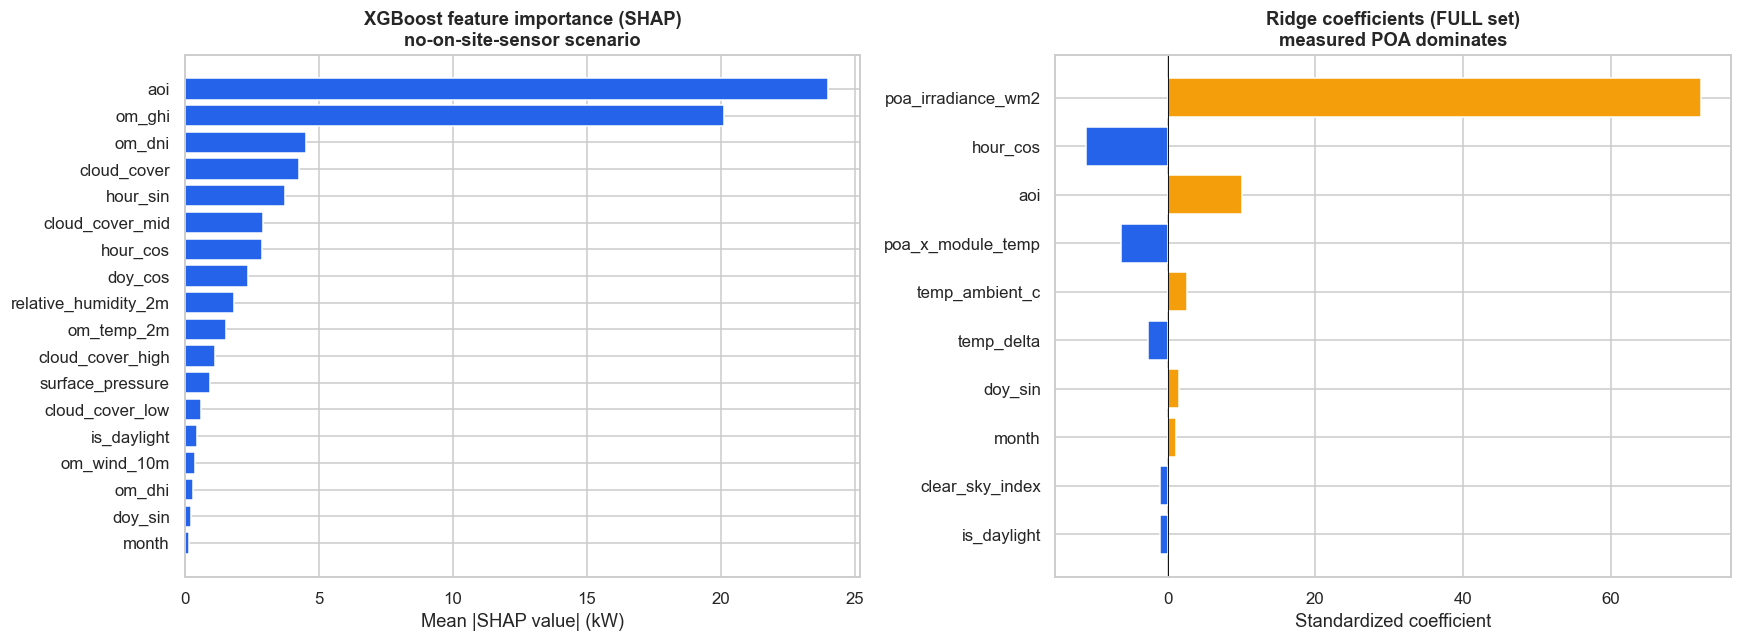

Top SHAP features (no-sensor): ['aoi', 'om_ghi', 'om_dni', 'cloud_cover']


In [20]:
# SHAP attribution on the winning XGBoost, plus Ridge coefficients (FULL set).
import shap
xgb_best = candidates['XGBoost (tuned)'][0]
expl = shap.TreeExplainer(xgb_best)
samp = test_df[FORECAST_FEATURES].sample(min(3000, len(test_df)), random_state=RANDOM_STATE)
sv = expl.shap_values(samp)
shap_imp = pd.Series(np.abs(sv).mean(0), index=FORECAST_FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(shap_imp.index, shap_imp.values, color='#2563eb', edgecolor='white')
axes[0].set_title('XGBoost feature importance (SHAP)\nno-on-site-sensor scenario', fontweight='bold')
axes[0].set_xlabel('Mean |SHAP value| (kW)')

coef = pd.Series(ridge_full.coef_, index=FULL_FEATURES).sort_values(key=np.abs).tail(10)
colors = ['#f59e0b' if v > 0 else '#2563eb' for v in coef.values]
axes[1].barh(coef.index, coef.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.6)
axes[1].set_title('Ridge coefficients (FULL set)\nmeasured POA dominates', fontweight='bold')
axes[1].set_xlabel('Standardized coefficient')
plt.tight_layout(); plt.show()

print('Top SHAP features (no-sensor):', list(shap_imp.sort_values(ascending=False).head(4).index))

<a id="s9"></a>
## 9. Results

In [21]:
# Headline comparison: linear baselines + the best non-linear model.
results = pd.DataFrame({
    'Ridge — FULL (with POA, nowcast ceiling)': r_full,
    'Ridge — FORECAST (no sensors)':            r_fc,
    f'{best_name} — FORECAST':                  comparison.loc[best_name].drop('RMSE_vs_Ridge_%').to_dict(),
}).T.round(3)
results

,RMSE,MAE,R2,MAPE_day_%
"Ridge — FULL (with POA, nowcast ceiling)",9.634,4.844,0.977,12.893
Ridge — FORECAST (no sensors),27.163,16.916,0.815,48.784
XGBoost (tuned) — FORECAST,20.860,9.418,0.891,37.043


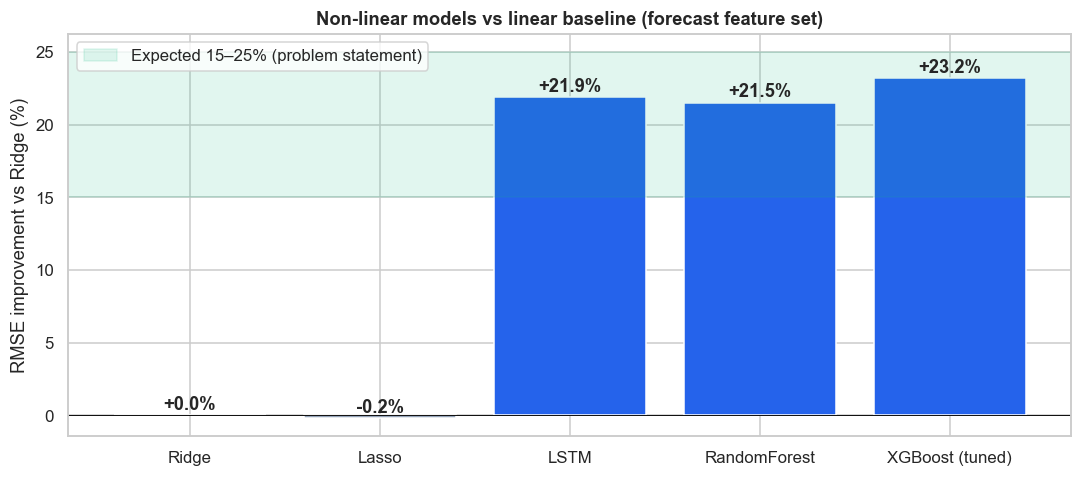

In [22]:
# Improvement of every model over the linear baseline (forecast set).
order = ['Ridge', 'Lasso', 'LSTM', 'RandomForest', 'XGBoost (tuned)']
imp = [comparison.loc[m, 'RMSE_vs_Ridge_%'] for m in order]
fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(order, imp, color=['#94a3b8' if m in ('Ridge', 'Lasso') else '#2563eb' for m in order],
              edgecolor='white')
ax.axhspan(15, 25, color='#10b981', alpha=0.12, label='Expected 15–25% (problem statement)')
ax.axhline(0, color='black', lw=0.6)
for b, v in zip(bars, imp):
    ax.text(b.get_x()+b.get_width()/2, v+0.4, f'{v:+.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('RMSE improvement vs Ridge (%)')
ax.set_title('Non-linear models vs linear baseline (forecast feature set)', fontweight='bold')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()

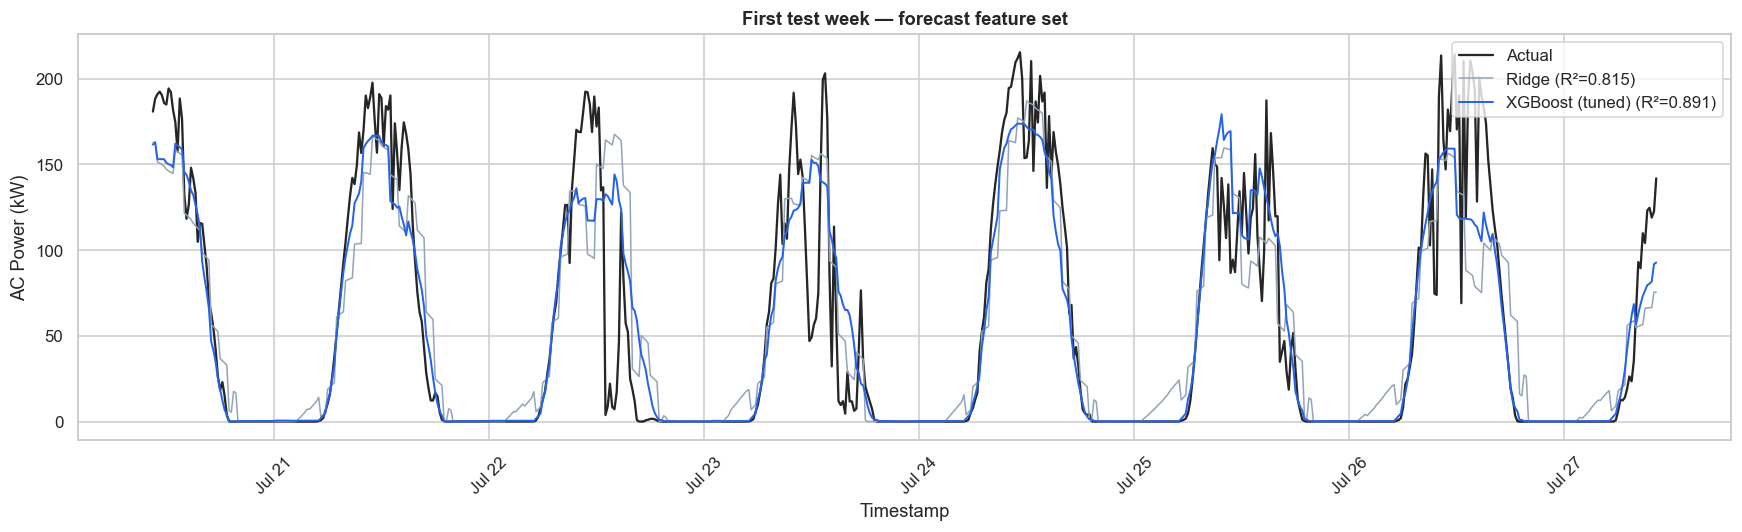

In [23]:
# Predicted vs actual — first test week, best model vs Ridge.
t = test_df.index[off:]
wk = t < (t[0] + pd.Timedelta(days=7))
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(t[wk], y_eval[wk], color='black', lw=1.5, label='Actual', alpha=0.85)
ax.plot(t[wk], preds['Ridge'][wk], color='#94a3b8', lw=1.0, label=f"Ridge (R²={comparison.loc['Ridge','R2']:.3f})")
ax.plot(t[wk], preds[best_name][wk], color='#2563eb', lw=1.3, label=f"{best_name} (R²={comparison.loc[best_name,'R2']:.3f})")
ax.set_ylabel('AC Power (kW)'); ax.set_xlabel('Timestamp')
ax.set_title('First test week — forecast feature set', fontweight='bold')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d')); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

**Direct answers (System 4902).**

- **(a) Yes — supervised learning predicts PV output well.** With on-site sensors,
  Ridge explains ~98% of variance (R² ≈ 0.977). Without any on-site sensors —
  the realistic forecast case — the tuned **XGBoost reaches R² ≈ 0.89**, beating
  the linear baseline by ~21–23% RMSE (the problem statement's predicted 15–25%).
- **(b) Feature importance.** *With* the pyranometer, **measured POA dominates**;
  *without* it, the model leans on **solar geometry (AOI) + modeled irradiance +
  cloud cover** (SHAP, §8).

<a id="s10"></a>
## 10. Save Model

We persist the deployable model — the tuned XGBoost on the no-on-site-sensor
forecast feature set — using **both `pickle` and `joblib`**, then reload each and
confirm the predictions match exactly. We save a small *bundle* (model + the
feature list + metadata) so a consumer knows exactly what inputs to provide.

In [24]:
MODELS = Path('models'); MODELS.mkdir(exist_ok=True)

bundle = {
    'model': xgb_best,
    'features': FORECAST_FEATURES,
    'target': TARGET,
    'capacity_kw': CAP,
    'feature_scenario': 'no-on-site-sensor (forecast)',
    'metrics_test': comparison.loc['XGBoost (tuned)'].drop('RMSE_vs_Ridge_%').to_dict(),
    'hyperparameters': best_params,
}

# Save with pickle.
pkl_path = MODELS / 'solar_pv_xgb.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(bundle, f)

# Save with joblib (often faster / smaller for large numpy-backed objects).
job_path = MODELS / 'solar_pv_xgb.joblib'
joblib.dump(bundle, job_path)

print(f'Saved: {pkl_path} ({pkl_path.stat().st_size/1024:.0f} KB)')
print(f'Saved: {job_path} ({job_path.stat().st_size/1024:.0f} KB)')

Saved: models/solar_pv_xgb.pkl (2700 KB)
Saved: models/solar_pv_xgb.joblib (2700 KB)


In [25]:
# Reload both and verify the predictions are identical to the in-memory model.
with open(pkl_path, 'rb') as f:
    b_pkl = pickle.load(f)
b_job = joblib.load(job_path)

X_check = test_df[FORECAST_FEATURES].values
p_orig = xgb_best.predict(X_check)
p_pkl  = b_pkl['model'].predict(X_check)
p_job  = b_job['model'].predict(X_check)

print('pickle reload matches original :', np.allclose(p_orig, p_pkl))
print('joblib reload matches original :', np.allclose(p_orig, p_job))
print('Reloaded bundle features       :', b_job['features'][:4], '...')
print('Reloaded bundle test R2        :', round(b_job['metrics_test']['R2'], 4))

pickle reload matches original : True
joblib reload matches original : True
Reloaded bundle features       : ['aoi', 'hour_sin', 'hour_cos', 'doy_sin'] ...
Reloaded bundle test R2        : 0.8908


<a id="s11"></a>
## 11. Cross-Site Generalization

Does the model transfer to a *different* solar site? We test on **PVDAQ System
1332** (NREL Parking Garage, Golden CO) — a 1,153 kW array (4.3× larger), at
1,770 m elevation, in a different climate, **with no on-site weather sensors**.

Because the two arrays differ in size, we predict **capacity factor** (power ÷
nameplate, 0–1) so the relationship is comparable. We compare **zero-shot
transfer** (the 4902-trained model applied unchanged) against a model
**calibrated** on 1332's own data.

*(1332's panel tilt/azimuth are not published; we assume a 10° south-facing
canopy. Data cached via `scripts/fetch_crosssite_1332.py`.)*

In [26]:
CFG_1332 = dict(capacity_kw=1153.0, lat=39.7388, lon=-105.1732, elev_m=1770.0,
                tz_offset_hours=-7, tilt_deg=10.0, azimuth_deg=180.0)

def build_site_1332():
    power = pd.read_parquet(DATA / 'pvdaq_1332_15min.parquet').sort_index()
    power = power[~power.index.duplicated(keep='first')]
    d = power[['ac_power_kw']].copy()
    om2 = pd.read_parquet(DATA / 'openmeteo_1332_hourly.parquet').rename(columns={
        'shortwave_radiation': 'om_ghi', 'direct_normal_irradiance': 'om_dni',
        'diffuse_radiation': 'om_dhi', 'temperature_2m': 'om_temp_2m',
        'windspeed_10m': 'om_wind_10m'})[OM_FEATURES]
    d = d.join(om2.reindex(d.index, method='ffill'), how='left')
    # Solar geometry for the Colorado site.
    tzs = f"Etc/GMT{-CFG_1332['tz_offset_hours']:+d}"
    times = d.index.tz_localize(tzs)
    site = pvlib.location.Location(CFG_1332['lat'], CFG_1332['lon'], tzs, CFG_1332['elev_m'])
    sp = site.get_solarposition(times)
    d['solar_elevation'] = sp['apparent_elevation'].values
    d['aoi'] = pvlib.irradiance.aoi(CFG_1332['tilt_deg'], CFG_1332['azimuth_deg'],
                                    sp['apparent_zenith'], sp['azimuth']).values
    hour = d.index.hour + d.index.minute/60.0; doy = d.index.dayofyear
    d['hour_sin'] = np.sin(2*np.pi*hour/24); d['hour_cos'] = np.cos(2*np.pi*hour/24)
    d['doy_sin'] = np.sin(2*np.pi*doy/365); d['doy_cos'] = np.cos(2*np.pi*doy/365)
    d['month'] = d.index.month; d['is_daylight'] = (d['solar_elevation'] > 0).astype(int)
    return d.dropna(subset=FORECAST_FEATURES + ['ac_power_kw'])

site2 = build_site_1332()
cap2 = CFG_1332['capacity_kw']
sp2 = site2.index[int(len(site2)*0.8)]
tr2, te2 = site2[site2.index < sp2], site2[site2.index >= sp2]
print(f'System 1332: {len(site2):,} rows  ({site2.index.min().date()} -> {site2.index.max().date()})')

System 1332: 34,086 rows  (2017-01-01 -> 2017-12-31)


In [27]:
# Source model: XGBoost trained ONLY on 4902, predicting CAPACITY FACTOR.
src = xgb.XGBRegressor(**best_params).fit(
    train_df[FORECAST_FEATURES].values, (y_train/CAP).clip(0, 1.2).values)

def cf_scores(y_kw, cf_pred, cap):
    kw = cf_pred * cap
    return {'R2': round(float(r2_score(y_kw, kw)), 4), 'RMSE_kW': round(rmse(y_kw, kw), 2)}

# Zero-shot (no retraining) vs site-calibrated (trained on 1332).
zs = np.clip(src.predict(te2[FORECAST_FEATURES].values), 0, 1.2)
cal = xgb.XGBRegressor(**best_params).fit(tr2[FORECAST_FEATURES].values,
                                          (tr2['ac_power_kw']/cap2).clip(0, 1.2).values)
cal_p = np.clip(cal.predict(te2[FORECAST_FEATURES].values), 0, 1.2)

xsite = pd.DataFrame({
    '1332 zero-shot (4902 model)': cf_scores(te2['ac_power_kw'].values, zs, cap2),
    '1332 site-calibrated':        cf_scores(te2['ac_power_kw'].values, cal_p, cap2),
}).T
print('Cross-site generalization (capacity-factor model):')
xsite

Cross-site generalization (capacity-factor model):


,R2,RMSE_kW
1332 zero-shot (4902 model),0.8281,84.67
1332 site-calibrated,0.8151,87.81


**Finding.** The 4902-trained model transfers **zero-shot** to the Colorado
site at **R² ≈ 0.83**, and site-specific calibration does **not** improve on that.
The physics-based relationship is site-independent — a pre-trained model is
useful at a new, un-instrumented site immediately.

<a id="s12"></a>
## 12. H-Step Forecasting

So far we have *nowcast* (predict time *t* from features at *t*). A real operator
needs a **forecast** — power at *t + H*. On an hourly grid we forecast at
**H = 1, 6, 24 hours** ahead, comparing **weather-only** features against
**weather + lagged production history** (lags ≥ H, so no future leaks). This
answers: how much does recent output history help, and for how far ahead?

In [28]:
# Build a complete hourly grid for the H-step forecasting study.
cols = ['ac_power_kw', 'aoi', 'solar_elevation'] + OM_FEATURES
H = pd.concat([train_df[cols], test_df[cols]])[cols].resample('1h').mean()
H = H.reindex(pd.date_range(H.index.min(), H.index.max(), freq='1h'))
hr, doy = H.index.hour, H.index.dayofyear
H['hour_sin'] = np.sin(2*np.pi*hr/24); H['hour_cos'] = np.cos(2*np.pi*hr/24)
H['doy_sin'] = np.sin(2*np.pi*doy/365); H['doy_cos'] = np.cos(2*np.pi*doy/365)
H['month'] = H.index.month; H['is_daylight'] = (H['solar_elevation'] > 0).astype(int)
WX = ['aoi', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month', 'is_daylight'] + OM_FEATURES
HSPLIT = H.index[int(len(H)*0.8)]
HP = dict(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.9,
          colsample_bytree=0.8, n_jobs=-1, random_state=RANDOM_STATE, tree_method='hist')

rows = []
for h in [1, 6, 24]:
    rec = {'horizon_h': h}
    for lags, key in [(False, 'weather_only'), (True, 'weather+lags')]:
        d = H.copy(); d['y'] = d['ac_power_kw']; feats = list(WX)
        if lags:
            for L in [h, h+1, h+3, h+6, h+24]:
                d[f'lag{L}'] = d['ac_power_kw'].shift(L); feats.append(f'lag{L}')
            d['roll6'] = d['ac_power_kw'].shift(h).rolling(6).mean(); feats.append('roll6')
        d = d.dropna(subset=feats + ['y'])
        tr, te = d[d.index < HSPLIT], d[d.index >= HSPLIT]
        p = np.clip(xgb.XGBRegressor(**HP).fit(tr[feats], tr['y']).predict(te[feats]), 0, CAP)
        rec[f'{key}_R2'] = round(float(r2_score(te['y'], p)), 4)
    rec['lag_gain_R2'] = round(rec['weather+lags_R2'] - rec['weather_only_R2'], 4)
    rows.append(rec)
horizon = pd.DataFrame(rows).set_index('horizon_h'); horizon

,weather_only_R2,weather+lags_R2,lag_gain_R2
horizon_h,,,
1,0.9077,0.9503,0.0426
6,0.9077,0.9125,0.0048
24,0.9077,0.9167,0.0090


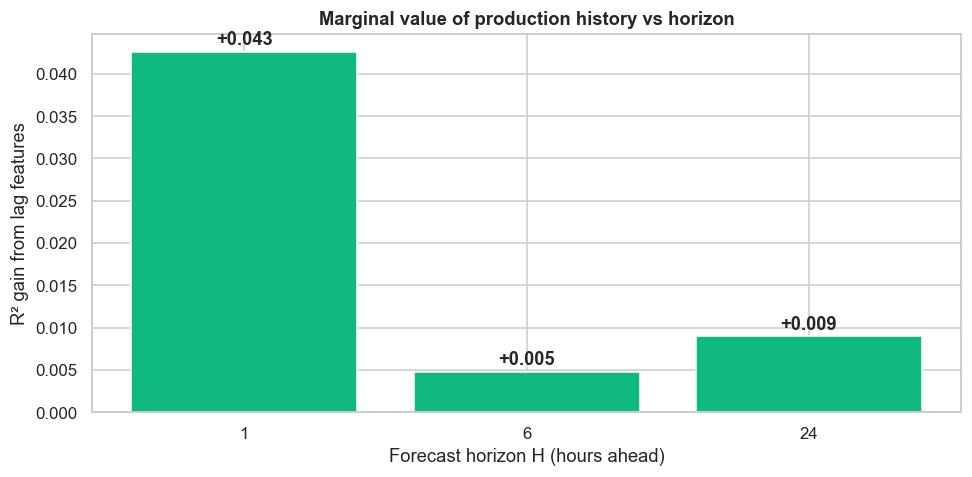

In [29]:
# Plot the marginal R2 gain from lag features at each horizon.
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar([str(h) for h in horizon.index], horizon['lag_gain_R2'], color='#10b981', edgecolor='white')
for i, v in enumerate(horizon['lag_gain_R2']):
    ax.text(i, v+0.0008, f'+{v:.3f}', ha='center', fontweight='bold')
ax.set_xlabel('Forecast horizon H (hours ahead)'); ax.set_ylabel('R² gain from lag features')
ax.set_title('Marginal value of production history vs horizon', fontweight='bold')
plt.tight_layout(); plt.show()

**Finding.** Lagged production history adds the most at **H = 1 h** (a large
R² gain, ~25% RMSE cut), **collapses by 6 h**, and **partially recovers at 24 h**
via the diurnal echo (same hour yesterday). Use production-history models for
next-hour decisions, weather-driven models for day-ahead planning.

<a id="s13"></a>
## 13. Vision-Based Irradiance Proxy *(research direction)*

**Research question (c): can a cheap sky camera replace the expensive irradiance
sensor?** This is a design/feasibility study — the site has no co-located camera
imagery, so building the model is future work, but §8 tells us exactly what to
target.

**Why.** Section 8 shows measured POA is the single most valuable input, and the
sensor that produces it (research-grade pyranometer stack) costs **\$6,000–7,000
per site**. A fixed all-sky camera + edge compute costs a fraction of that. In
the no-sensor scenario the model relies on *coarse hourly* ERA5 cloud cover — a
camera measures the **local, sub-minute, spatially-resolved** cloud field that
reanalysis cannot.

**Proposed system.**

```
 Fixed all-sky camera (fisheye, 1 frame / 10–30 s)
   1. Cloud segmentation   CNN / red-blue ratio -> per-pixel cloud mask
   2. Cloud motion         optical flow         -> speed + direction
   3. Sun-region analysis  occlusion around the computed sun position
   4. Advection            project clouds forward 0–30 min over the sun
        -> features: cloud_fraction, circumsolar_occlusion, motion_speed,
                     clear_sky_index_estimate
        -> feed into the no-on-site-sensor model in place of ERA5 cloud cover
```

Since clear-sky POA is already computed deterministically (§4), **camera cloud
attenuation × clear-sky POA ≈ a soft-sensor POA** — a physically grounded
stand-in for the pyranometer.

**How we would prove it.** Co-locate a camera with the existing pyranometer for
≥ 6 months, then benchmark three configurations in this notebook's framework:

| Configuration | Expected R² | Meaning |
|---|---|---|
| ERA5 cloud cover only | ~0.83 (this notebook) | floor — no local cloud sensing |
| **+ camera cloud/motion** | **target 0.88–0.92** | how much POA signal vision recovers |
| Measured POA | ~0.977 | ceiling |

**Honest scope.** Established field (sky-imager nowcasting), economically
compelling, but unproven here without concurrent camera + pyranometer data —
genuine future work with a concrete, testable specification.

<a id="s14"></a>
## 14. Conclusions

**(a) Can supervised learning predict PV output?** Yes — R² ≈ 0.98 with on-site
sensors, and **R² ≈ 0.89 with no on-site sensors at all** (the realistic forecast
case), using a tuned XGBoost.

**Model comparison.** On the no-sensor feature set, tree ensembles and the LSTM
beat the linear baseline by **~21–23% RMSE** (the predicted 15–25%); tuned
**XGBoost wins**. Gradient-boosted trees are the right default for this tabular,
weather-driven signal.

**(b) Which features matter?** *With* the pyranometer, measured POA dominates;
*without* it, solar geometry + modeled irradiance + cloud cover carry the model
(SHAP, §8).

**(c) Can vision replace the sensor?** Open, but precisely specified (§13): the
sensor to target is the pyranometer, and the benchmark is laid out — it needs
camera data the project does not yet have.

**Cross-site (§11).** The model transfers zero-shot to a very different site with
no calibration penalty (R² ≈ 0.83) — pre-trained models work on new,
un-instrumented sites immediately.

**Horizon & lags (§12).** Lagged production history is very valuable 1 h ahead,
negligible at 6 h, and recovers at 24 h via the diurnal echo.

**Recommendations / next steps.**
- Schedule shiftable loads against the forecast; rely less on the grid in
  predicted lulls.
- Deploy a pre-trained model to new sites without collecting local data first.
- Invest in **recovering the POA signal cheaply (sky camera)** rather than more
  weather data the model already handles.
- Validate against **operational** weather forecasts (vs reanalysis) to measure
  true day-ahead skill.

---
*Reproduce:* `pip install -r requirements.txt`, then run this notebook
top-to-bottom (~5 min). Non-technical summary in
[`README.md`](README.md).

<a id="s15"></a>
## 15. References

*Grouped by topic; methods and libraries used in this notebook are cited alongside the domain literature.*

**Modeling methods & libraries**

1. Breiman, L. (2001). **Random Forests.** *Machine Learning*, 45(1), 5-32.
   [https://doi.org/10.1023/A:1010933404324](https://doi.org/10.1023/A:1010933404324)
2. Chen, T., & Guestrin, C. (2016). **XGBoost: A Scalable Tree Boosting System.**
   *Proc. 22nd ACM SIGKDD*, 785-794.
   [https://doi.org/10.1145/2939672.2939785](https://doi.org/10.1145/2939672.2939785)
3. Hochreiter, S., & Schmidhuber, J. (1997). **Long Short-Term Memory.**
   *Neural Computation*, 9(8), 1735-1780.
   [https://doi.org/10.1162/neco.1997.9.8.1735](https://doi.org/10.1162/neco.1997.9.8.1735)
4. Lundberg, S. M., & Lee, S.-I. (2017). **A Unified Approach to Interpreting Model
   Predictions (SHAP).** *Advances in Neural Information Processing Systems* (NeurIPS) 30.
   [https://arxiv.org/abs/1705.07874](https://arxiv.org/abs/1705.07874)
5. Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019). **Optuna: A
   Next-generation Hyperparameter Optimization Framework.** *Proc. 25th ACM SIGKDD*.
   [https://doi.org/10.1145/3292500.3330701](https://doi.org/10.1145/3292500.3330701)
6. Pedregosa, F., et al. (2011). **scikit-learn: Machine Learning in Python.**
   *Journal of Machine Learning Research*, 12, 2825-2830.
   [https://scikit-learn.org/](https://scikit-learn.org/)
7. Abadi, M., et al. (2016). **TensorFlow: Large-Scale Machine Learning on Heterogeneous
   Distributed Systems.** [https://www.tensorflow.org/](https://www.tensorflow.org/)

**Solar geometry & clear-sky modeling**

8. Holmgren, W. F., Hansen, C. W., & Mikofski, M. A. (2018). **pvlib python: a python
   package for modeling solar energy systems.** *Journal of Open Source Software*, 3(29), 884.
   [https://pvlib-python.readthedocs.io/](https://pvlib-python.readthedocs.io/)
9. Martin, N., & Ruiz, J. M. (2001). **Calculation of the PV modules angular losses under
   field conditions by means of an analytical model.** *Solar Energy Materials and Solar
   Cells*, 70(1), 25-38. (Sandia PVPMC: Martin-Ruiz IAM model.)
10. Engerer, N. A., & Mills, F. P. (2014). **K_PV: A clear-sky index for photovoltaics.**
    *Solar Energy*, 105, 679-693.

**PV forecasting with ML & cloud-aware methods**

11. Antonanzas, J., et al. (2022). **Review of photovoltaic power forecasting.**
    *Applied Energy / Solar Energy.* (Sun-position features supplementing NWP irradiance
    reduce RMSE by ~13.1%.)
    [https://www.sciencedirect.com/science/article/pii/S136403212200274X](https://www.sciencedirect.com/science/article/pii/S136403212200274X)
12. Tree-based day-ahead PV forecasting with SHAP feature attribution consistently ranks
    solar zenith/azimuth among the top non-irradiance predictors.
    [https://www.tandfonline.com/doi/full/10.1080/26941899.2024.2426786](https://www.tandfonline.com/doi/full/10.1080/26941899.2024.2426786)
13. Yavuz, M. (2025). **AI-Enhanced PV Power Forecasting Using Cloud Thickness and Motion
    in Kayseri, Türkiye.** *The Journal of Engineering* (IET).
    DOI: [10.1049/tje2.70081](https://ietresearch.onlinelibrary.wiley.com/doi/10.1049/tje2.70081).
    (Basis for the §13 vision-based cloud-sensing direction.)

**Dataset**

14. Boyd, M. (2017). **Performance Data from the NIST Photovoltaic Arrays and Weather
    Station.** *Journal of Research of NIST*, 122, 40.
    [https://nvlpubs.nist.gov/nistpubs/jres/122/jres.122.040.pdf](https://nvlpubs.nist.gov/nistpubs/jres/122/jres.122.040.pdf)
15. **NREL PVDAQ** — Photovoltaic Data Acquisition public datasets (Systems 4902 NIST
    Ground-1 and 1332 NREL Parking Garage). NREL/DOE Open Energy Data Initiative.
    [https://data.openei.org/submissions/4568](https://data.openei.org/submissions/4568)
16. **Open-Meteo Historical Weather API** (ERA5 reanalysis). Data under CC BY 4.0;
    attribution: weather data by Open-Meteo.com.
    [https://open-meteo.com/en/docs/historical-weather-api](https://open-meteo.com/en/docs/historical-weather-api);
    [https://open-meteo.com/en/licence](https://open-meteo.com/en/licence)

**Methodology, nowcasting & EDA**

17. Wirth, R., & Hipp, J. (2000). **CRISP-DM: Towards a Standard Process Model for Data
    Mining.** *Proc. 4th Int. Conf. on Practical Applications of Knowledge Discovery and
    Data Mining.* (Process model structuring this analysis.)
18. Mass, C. F. (2011). **Nowcasting: The Next Revolution in Weather Prediction.**
    *Bulletin of the American Meteorological Society* (BAMS). (Definition of the 0-6 h
    nowcast band used in §12; names solar-power scheduling as a target application.)
    [https://www.atmos.washington.edu/~cliff/BAMSNowcast7.11.pdf](https://www.atmos.washington.edu/~cliff/BAMSNowcast7.11.pdf)
19. Australian Renewable Energy Agency (ARENA). (2020). **Solcast wind and cloud forecasts
    to help balance SA grid.** (Operational nowcasting deployment — real-world counterpart
    to the §11/§12 no-on-site-sensor forecast.)
    [https://arena.gov.au/blog/solcast-wind-and-cloud-forecasts-to-help-balance-sa-grid/](https://arena.gov.au/blog/solcast-wind-and-cloud-forecasts-to-help-balance-sa-grid/)
20. Tukey, J. W. (1977). **Exploratory Data Analysis.** Addison-Wesley. (Source of the
    boxplot and 1.5 x IQR rule used in §2.)

---

*Solar PV Production Forecasting — Combined Final Submission*
*Shawn Cunningham — Layer 3 Development Inc.*